# Measurement x=15, y=0, z=0

### TODO

- implement hyperopt
- time-delayes readout learning (Takens) (as parameter)
- Lasso
- whole plane
- whole plane 3d
- more inputs (in 3d?)

### Imports

In [307]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import reservoirpy as rpy
from reservoirpy.nodes import Reservoir
from reservoirpy.nodes import Ridge
from reservoirpy.nodes import Input


from ppvm_py.utils import load_object

from ppvm_py.yz_slice_utils import find_closest_coordinate_index

from ppvm_py.plotting import plot_timeseries

from ppvm_py.data_processing.yz_slice import print_yz_slice_example_from_parsed_data
from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.feature_generation.sdc import symmetric_difference_coefficient
from ppvm_py.feature_generation.pdm import pdm_approximated_velocity

### General Args

In [308]:
random_seed = 4629837

# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 300

if Ha == 300:
    slice_folder_path = Path("../../../../data/4pi_re1000_ha300.360_ch28.p1/SliceYZ_x0015/")
elif Ha == 1000:
    slice_folder_path = Path("../../../../data/4pi_re1000_ha1000.384.pi/SliceYZ_x0015/")

# Estimates in determining_sigma_and_magnetic_field_strength.ipynb
sigma = -1
B_z = -1

test_size = 0.3

### Preamble

In [309]:
mses = {}  # Dict for gathering mean-squared-errors.

np.random.seed(random_seed)

### Load Data

In [310]:
fld_path = slice_folder_path / Path("pkl/sliceYZ_x0015_fld.pkl")
gradF_path = slice_folder_path / Path("pkl/sliceYZ_x0015_gradF.pkl")

In [311]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(fld_data)
print()

if 'gradF_data' not in locals():
    gradF_data = load_object(gradF_path)
gradF_data['index_to_coord_map'] = create_index_to_coord_map(gradF_data['coord_to_index_map'])
print_yz_slice_example_from_parsed_data(gradF_data)

n_t, n_y, n_z, n_v = fld_data['timeseries'].shape  # N = num snapshots

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 y, first 2 z) with coordinates:
  (y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.027423e-01  0.000000e+00
  0.000000e+00 -5.862112e-04  1.594463e+00]
  (y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000000e+00 -2.175437e-01  0.000000e+00
 -4.764620e-01 -5.860972e-04  1.599692e+00]
  (y=-0.99, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.220912e-01  2.072063e+00
  0.000000e+00 -5.841985e-04  1.580085e+00]
  (y=-0.99, z=-0.99): [ 2.256158e+00 -1.132797e-01  1.513446e-02 -2.226841e-01 -5.704941e-02
 -3.949543e-01 -5.842091e-04  1.584242e+00]

The data looks as follows:
N (number of snapshots) = 20000
n_y (grid height) = 46, n_z (grid width) = 46, n_v (number of variables) = 3
Labels:
['dfdx', 'dfdy', 'dfdz']
Preview of the first

### Get Existing x and y Coordinates

In [312]:
y_coord_desired = 0
z_coord_desired = 0

# Adjust according to error message. No error will be thrown after correct adjustment.
# y_coord = y_coord_desired
# z_coord = z_coord_desired
if Ha == 300:
    y_coord = -0.01842125
    z_coord = -0.01842125
elif Ha == 1000:
    y_coord = 0
    z_coord = 0

i_y_center, i_z_center = find_closest_coordinate_index(
    fld_data['coord_to_index_map'],
    y_coord=y_coord,
    z_coord=z_coord,
)
output_indices = (
    slice(None),
    i_y_center,
    i_z_center,
)

### Define Train and Test Set

In [313]:
fld_data_train, fld_data_test = train_test_split(
    fld_data['timeseries'],
    test_size=test_size,
    shuffle=False,
)

# train
output_indices_shape_train = fld_data_train[output_indices].shape[:-1]
n_output_indices_train = int(np.prod(list(output_indices_shape_train)))

# test
output_indices_shape_test = fld_data_test[output_indices].shape[:-1]
n_output_indices_test = int(np.prod(list(output_indices_shape_test)))

n_time_output_indices_test = output_indices_shape_test[0]
n_spatial_output_indices_test = int(np.prod(output_indices_shape_test[1:]))

### Define $y_{\text{true}}$

In [314]:
# train
y_true_train = fld_data_train[
    ...,
    fld_data['labels'].index('vx'),
]

# Train SS on all training data to make it comparable to other output_indices.
# Every grid point is an output feature. The scaling must not be different between these features => train SS on all data together.
ss_y_true = StandardScaler()
ss_y_true.fit(y_true_train.reshape(-1, 1))

y_true_train = y_true_train[output_indices]
y_true_train = ss_y_true.transform(
    y_true_train.reshape(-1, 1),
).reshape(*output_indices_shape_train)


# test
y_true_test = fld_data_test[
    ...,
    fld_data['labels'].index('vx'),
]
y_true_test = y_true_test[output_indices]
y_true_test = ss_y_true.transform(
    y_true_test.reshape(-1, 1),
).reshape(*output_indices_shape_test)

### Get Input $\phi$

In [315]:
# phi_standard_scaler
phi_train = fld_data_train[
    ...,
    fld_data['labels'].index('F'),
]
ss_phi = StandardScaler()
ss_phi.fit(phi_train.reshape(-1, 1))

# train
shape_ = phi_train.shape
phi_train = ss_phi.transform(phi_train.reshape(-1, 1)).reshape(shape_)

# test
phi_test = fld_data_test[
    ...,
    fld_data['labels'].index('F'),
]
shape_ = phi_test.shape
phi_test = ss_phi.transform(phi_test.reshape(-1, 1)).reshape(shape_)

### General Benchmark

Assuming we know $j_y$ and the measurement distance of potentials can be infinitesimal small, we can use the partial derivative $\frac{\partial{\phi}}{\partial{y}}$ of the potential. With this, we can calculate the $v_x$ exactly using Ohm's law. The remainder is simulation error.

This error is taken as benchmark to compare all methods against.

mse(part + j) = 0.025727040824984036


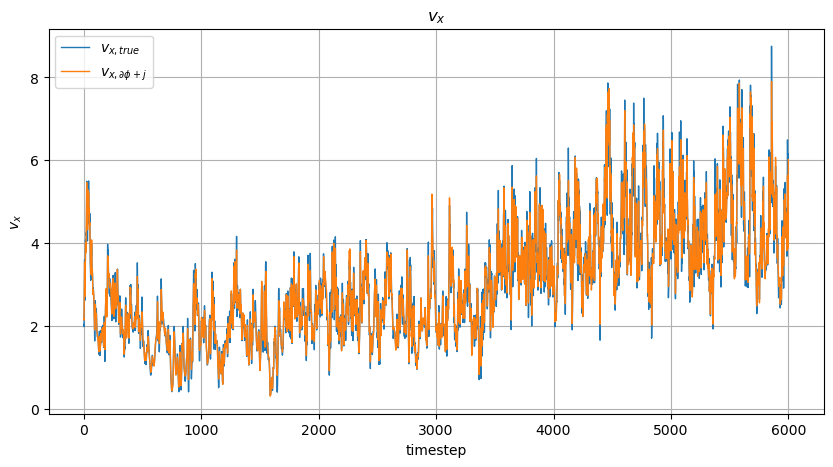

In [316]:
part_phi_y = gradF_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    gradF_data['labels'].index('dfdy'):gradF_data['labels'].index('dfdy') + 1,
]
j_y_center = fld_data['timeseries'][
    :,
    i_y_center,
    i_z_center,
    fld_data['labels'].index('jy'):fld_data['labels'].index('jy') + 1,
]

(
    part_phi_y_train,
    part_phi_y_test,
    j_y_center_train,
    j_y_center_test
) = train_test_split(
    part_phi_y,
    j_y_center,
    test_size=test_size,
    shuffle=False,
)
v_x_ohms_law_test = (part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_ohms_law_test = ss_y_true.transform(
    v_x_ohms_law_test,
    copy=False,
)
mse_ohms_law = mean_squared_error(y_true_test, y_pred_ohms_law_test)
mses['General Benchmark'] = mse_ohms_law
print(f"mse(part + j) = {mse_ohms_law}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_ohms_law_test,
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, \\partial{\\phi} + j}$",
    ],
    title="$v_x$",
    xlabel="timestep",
    ylabel="$v_x$",
)

### Potential Difference Method (SDC) Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. This is also called *Potential Difference Method*. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Define Points $y_1$ and $y_2$

y_1_y = (y_1_y, y_1_z)

y_2_y = (y_2_y, y_2_z)

y_1_y < y_coord < y_2_y

y_1_z = z_coord = y_2_z

In [317]:
# """Coordinates by using delta_l
# """

# delta_l = 0.1  # y, z domain = [-1, 1]


# # Find y_1
# y_1_y_desired = y_coord - delta_l / 2
# y_1_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_1_y = y_1_y_desired
# # y_1_z = y_1_z_desired
# if Ha == 300:
#     y_1_y = -0.05560156
#     y_1_z = -0.01842125
# elif Ha == 1000:
#     y_1_y = -0.03460649
#     y_1_z = 0.0

# i_y_1_y, i_y_1_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_1_y,
#     z_coord=y_1_z,
#     )


# # Find y_2
# y_2_y_desired = y_coord + delta_l / 2
# y_2_z_desired = z_coord

# # Adjust according to error message. No error will be thrown after correct adjustment.
# # y_2_y = y_2_y_desired
# # y_2_z = y_2_z_desired
# if Ha == 300:
#     y_2_y = 0.01842125
#     y_2_z = -0.01842125
# elif Ha == 1000:
#     y_2_y = 0.03460649
#     y_2_z = 0.0

# i_y_2_y, i_y_2_z = find_closest_coordinate_index(
#     fld_data['coord_to_index_map'],
#     y_coord=y_2_y,
#     z_coord=y_2_z,
#     )

In [318]:
"""Coordinates by using delta_i
"""

delta_i = 1


i_y_1_y = i_y_center - delta_i
i_y_1_z = i_z_center

i_y_2_y = i_y_center + delta_i
i_y_2_z = i_z_center

y_1_y, y_1_z = fld_data['index_to_coord_map'][i_y_1_y, i_y_1_z]
y_2_y, y_2_z = fld_data['index_to_coord_map'][i_y_2_y, i_y_2_z]

In [319]:
"""Coordinate Checkup
"""
print(f"Center: y = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}, z = {fld_data['index_to_coord_map'][i_y_center, i_z_center]}")
print()
print(f"y_1 Coordinates: y = {y_1_y}, z = {y_1_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_1 = {y_1_y - y_coord}, delta_z^y_1 = {y_1_z - z_coord}, ", end='')
print(f"delta_i_y^y_1 = {i_y_1_y - i_y_center}, delta_i_z^y_1 = {i_y_1_z - i_z_center}")
print()
print(f"y_2 Coordinates: y = {y_2_y}, z = {y_2_z}")
print(f"Difference to center: ", end='')
print(f"delta_y^y_2 = {y_2_y - y_coord}, delta_z^y_2 = {y_2_z - z_coord}, ", end='')
print(f"delta_i_y^y_2 = {i_y_2_y - i_y_center}, delta_i_z^y_2 = {i_y_2_z - i_z_center}")
print()
delta_y = y_2_y - y_1_y
delta_z = y_2_z - y_1_z
print(f"Difference between y_1 to y_2: ", end='')
print(f"delta_y = {delta_y}, delta_z = {delta_z}, ", end='')
print(f"delta_i_y = {i_y_2_y - i_y_1_y}, delta_i_z = {i_y_2_z - i_y_1_z}")

Center: y = (-0.01842125, -0.01842125), z = (-0.01842125, -0.01842125)

y_1 Coordinates: y = -0.05560156, z = -0.01842125
Difference to center: delta_y^y_1 = -0.03718031, delta_z^y_1 = 0.0, delta_i_y^y_1 = -1, delta_i_z^y_1 = 0

y_2 Coordinates: y = 0.01842125, z = -0.01842125
Difference to center: delta_y^y_2 = 0.0368425, delta_z^y_2 = 0.0, delta_i_y^y_2 = 1, delta_i_z^y_2 = 0

Difference between y_1 to y_2: delta_y = 0.07402281, delta_z = 0.0, delta_i_y = 2, delta_i_z = 0


##### Prepare Data

In [320]:
# train
phi_y_1_train = phi_train[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_train = phi_train[
    :,
    i_y_2_y,
    i_y_2_z,
]

# test
phi_y_1_test = phi_test[
    :,
    i_y_1_y,
    i_y_1_z,
]
phi_y_2_test = phi_test[
    :,
    i_y_2_y,
    i_y_2_z,
]

##### Testing

mse(pdm_j) = 0.10477532274126165


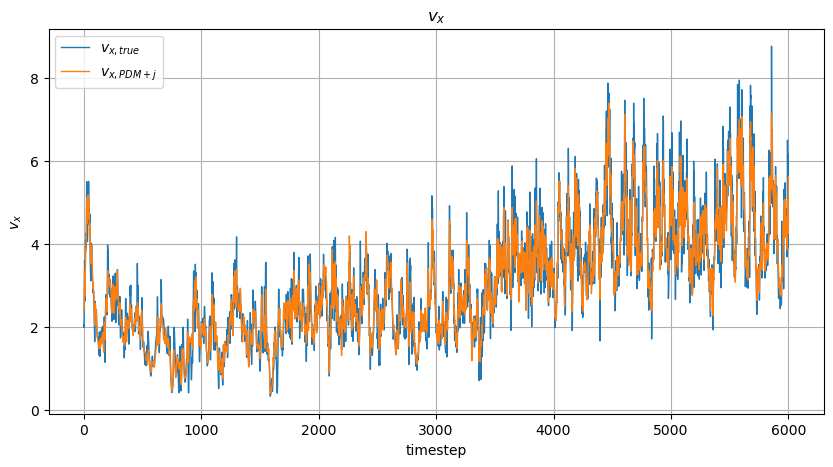

In [321]:
approx_part_phi_y_test = symmetric_difference_coefficient(
    former_point=ss_phi.inverse_transform(phi_y_1_test.reshape(-1, 1)),
    latter_point=ss_phi.inverse_transform(phi_y_2_test.reshape(-1, 1)),
    delta_l=delta_y,
).reshape(-1, 1)
v_x_sdc_test = (approx_part_phi_y_test - (j_y_center_test / sigma)) / B_z
y_pred_sdc_test = ss_y_true.transform(
    v_x_sdc_test,
    copy=False,
)
mse_sdc = mean_squared_error(
    y_true_test.reshape(
        n_time_output_indices_test,
        n_spatial_output_indices_test,
    ),
    y_pred_sdc_test.reshape(
        n_time_output_indices_test,
        n_spatial_output_indices_test,
    ),
)
mses['PDM Benchmark'] = mse_sdc
print(f"mse(pdm_j) = {mse_sdc}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_sdc_test,
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, PDM + j}$",
    ],
    title="$v_x$",
    xlabel="timestep",
    ylabel="$v_x$",
)

### Echo State Network + Ridge

In [ ]:
n_hidden_neurons = 100
neuron_leak_rate = 1  # default = 1
w_spectral_radius = None  # default = None
input_scaling =  1.0  # default = 1.0

n_warmup_train = 100
n_warmup_test = 100

regularization_scale = 1e-7

rpy_verbosity = 0

# phi_center_train = np.sin(np.linspace(0, 6*np.pi, n_t)).reshape(-1, 1)

##### Prepare Data

In [323]:
# train
phi_center_train = phi_train[
    :,
    i_y_center,
    i_z_center,
].reshape(-1, 1)
X_train = np.stack(
    [
        phi_center_train.squeeze(),
        phi_y_1_train,
        phi_y_2_train,
    ],
    axis=1,
)

# test
phi_center_test = phi_test[
    :,
    i_y_center,
    i_z_center,
].reshape(-1, 1)
X_test = np.stack(
    [
        phi_center_test.squeeze(),
        phi_y_1_test,
        phi_y_2_test,
    ],
    axis=1,
)

# on train data
# y_true_test = y_true_train
# X_test = X_train

##### ESN-Ridge Model Creation

In [324]:
rpy.verbosity(rpy_verbosity)
rpy.set_seed(random_seed)

reservoir = Reservoir(
    units=n_hidden_neurons,
    lr=neuron_leak_rate,
    sr=w_spectral_radius,
    input_scaling=input_scaling,
)
readout = Ridge(
    ridge=regularization_scale,
)
input = Input()

esn_ridge = [input, input >> reservoir] >> readout
esn_ridge.initialize(
    X_train[0],
    y_true_train.reshape(-1, 1)[0],
)

random_init_state = np.random.uniform(-1, 1, size=(1, reservoir.output_dim))
init_state = random_init_state

##### Training

In [325]:
esn_ridge = esn_ridge.fit(
    X_train,
    y_true_train.reshape(-1, 1),
    warmup=n_warmup_train,
    from_state={
        reservoir.name : init_state,
    },
)

##### Testing

mse(esn-ridge) = 0.7216476647659378


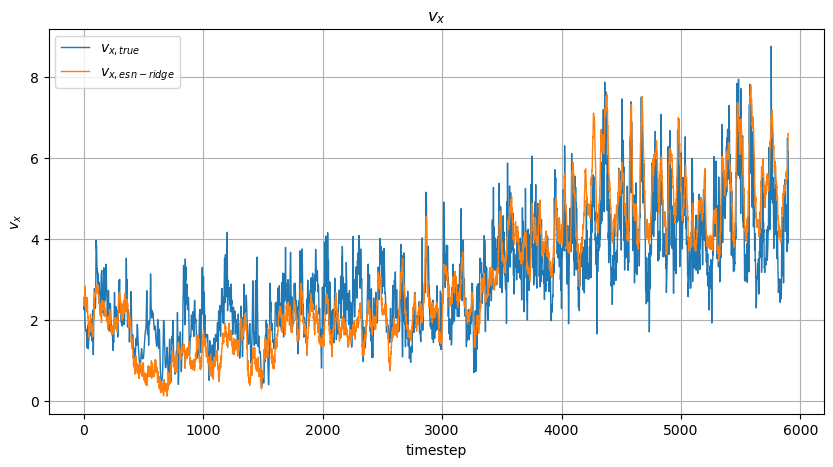

In [326]:
y_pred_esn_ridge_test = esn_ridge.run(
    X_test,
    from_state={
        reservoir.name : init_state,
    },
    return_states=[readout.name],
)
y_pred_esn_ridge_test = y_pred_esn_ridge_test[readout.name]

mse_esn_ridge = mean_squared_error(
    y_true_test[n_warmup_test:],
    y_pred_esn_ridge_test[n_warmup_test:],
)
mses['esn-ridge'] = mse_esn_ridge
print(f"mse(esn-ridge) = {mse_esn_ridge}")
plot_timeseries(
    data_list=[
        y_true_test[n_warmup_test:],
        y_pred_esn_ridge_test[n_warmup_test:],
    ],
    labels=[
        "$v_{x, true}$",
        "$v_{x, esn-ridge}$",
    ],
    title="$v_x$",
    xlabel="timestep",
    ylabel="$v_x$",
)

### Comparison

In [327]:
mses

{'General Benchmark': 0.025727040824984036,
 'PDM Benchmark': 0.10477532274126165,
 'esn-ridge': 0.7216476647659378}